# №2 (5 баллов)
[Скачайте файл с данными о публикациях на сайте Хабрахабр](https://cloud.mail.ru/public/3ViL/q5xSM1TH2).

1. Изучите датасет, попробуйте понять какой столбец за что отвечает.

In [17]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sb

def print_col_dtype(df):
    print(pd.DataFrame({
    'Столбец': df.columns,
    'Тип_данных': [str(dtype) for dtype in df.dtypes]
    }).to_string(index=False))
    print("\n\n")

df = pd.read_csv('howpop_train.csv')
print("Названия столбцов и типы данных:")
print_col_dtype(df)

Названия столбцов и типы данных:
         Столбец Тип_данных
             url     object
          domain     object
         post_id      int64
       published     object
          author     object
            flow     object
         polling     object
     content_len     object
           title     object
        comments      int64
            favs      int64
           views     object
      votes_plus     object
     votes_minus     object
   views_lognorm     object
    favs_lognorm     object
comments_lognorm     object
     Unnamed: 17     object
     Unnamed: 18    float64





C:\Users\user\AppData\Local\Temp\ipykernel_9544\2141990845.py:13: DtypeWarning: Columns (6,7,11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('howpop_train.csv')


2. Удалите столбцы, названия которых заканчиваются на _lognorm. Выберите их с помощью `filter()` и удалите `drop`-ом:
```
df.drop(
    filter(lambda c: c.endswith("_lognorm"), df.columns),
    axis=1,         # axis = 1: столбцы
    inplace=True,
) # избавляет от необходимости сохранять датасет
```

In [18]:
df.drop(
    filter(lambda c: c.endswith("_lognorm"), df.columns),
    axis=1,
    inplace=True)

print_col_dtype(df)
print("Видим что столбцы заканч. на _lognorm удалены.")

    Столбец Тип_данных
        url     object
     domain     object
    post_id      int64
  published     object
     author     object
       flow     object
    polling     object
content_len     object
      title     object
   comments      int64
       favs      int64
      views     object
 votes_plus     object
votes_minus     object
Unnamed: 17     object
Unnamed: 18    float64



Видим что столбцы заканч. на _lognorm удалены.


3. Столбец `published` (время публикации) содержит строки. Чтобы работать с этими данными как с датой/временем публикации, приведите их к типу `datetime`:
`df["published"] = pd.to_datetime(df.published, yearfirst=True)`

In [20]:
df["published"] = pd.to_datetime(df.published, yearfirst=True)
print("\nТип данных после преобразования: ")
print(f'"published": {df["published"].dtype}')


Тип данных после преобразования: 
"published": datetime64[ns]


4. Создайте несколько столбцов на основе данных о времени публикации:

```
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]

df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]
```


In [21]:
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]

df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]

print_col_dtype(df)

    Столбец     Тип_данных
        url         object
     domain         object
    post_id          int64
  published datetime64[ns]
     author         object
       flow         object
    polling         object
content_len         object
      title         object
   comments          int64
       favs          int64
      views         object
 votes_plus         object
votes_minus         object
Unnamed: 17         object
Unnamed: 18        float64
       year          int64
      month          int64
  dayofweek          int64
       hour          int64





5. Используя Seaborn, постройте визуализацию и покажите в каком месяце (и какого года) было больше всего публикаций.

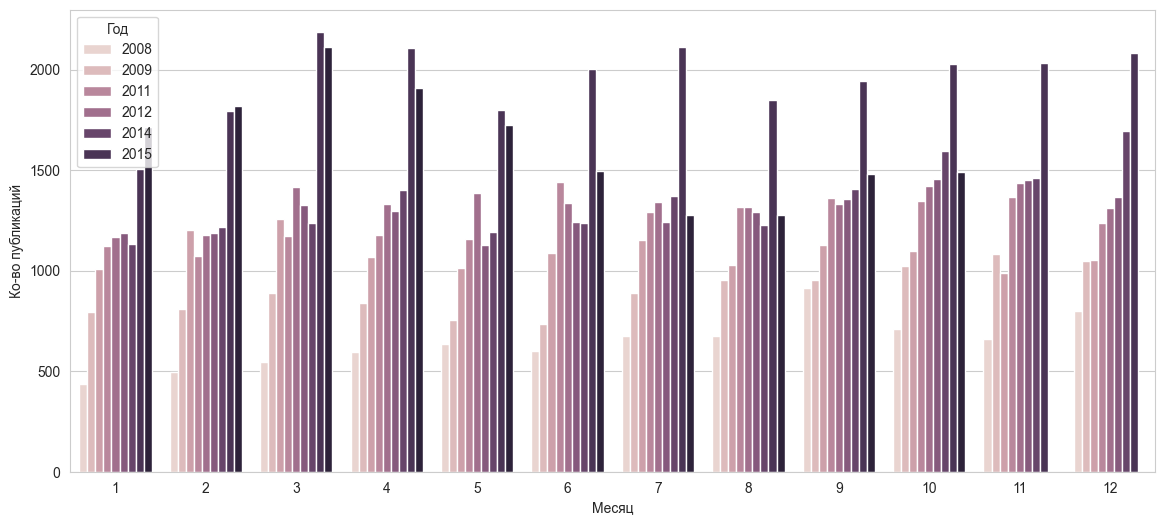

In [36]:
monthly_counts = df.groupby(['year', 'month']).size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sb.barplot(data=monthly_counts, x='month', y='count', hue='year')
plt.xlabel('Месяц')
plt.ylabel('Ко-во публикаций')
plt.legend(title='Год')
plt.show()

6. Используя Seaborn, постройте график зависимости числа публикаций от дня недели, используя параметр hue.

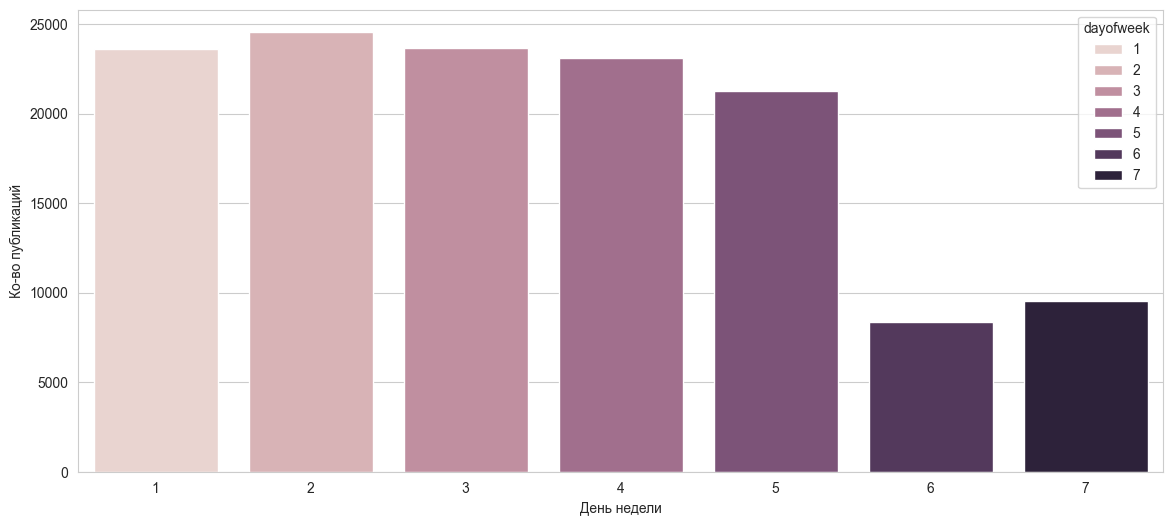

In [41]:
daily_counts = df.groupby('dayofweek').size().reset_index(name='count')

plt.figure(figsize=(14, 6))
sb.barplot(data=daily_counts, x='dayofweek', y='count', hue='dayofweek')
plt.xlabel('День недели')
plt.ylabel('Ко-во публикаций')
plt.show()

7. Используя Seaborn, проведите визуальный анализ и отметьте верные утверждения про данный датасет:
- Больше всего просмотров набирают статьи, опубликованные в 12 часов дня
- У опубликованных в 10 утра постов больше всего комментариев
- Больше всего просмотров набирают статьи, опубликованные в 6 часов утра
- Максимальное число комментариев на гиктаймсе набрала статья, опубликованная в 9 часов вечера
- На хабре дневные статьи комментируют чаще, чем вечерние

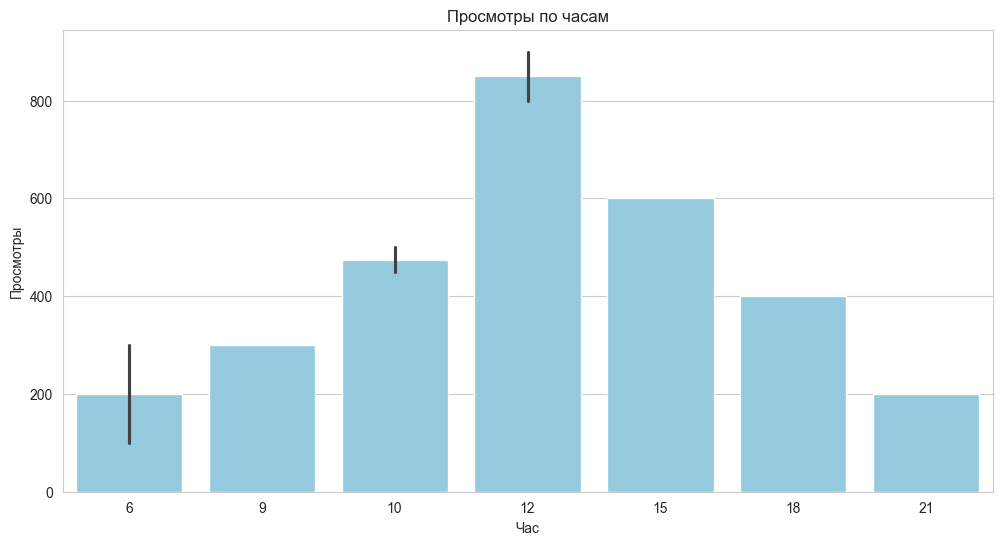

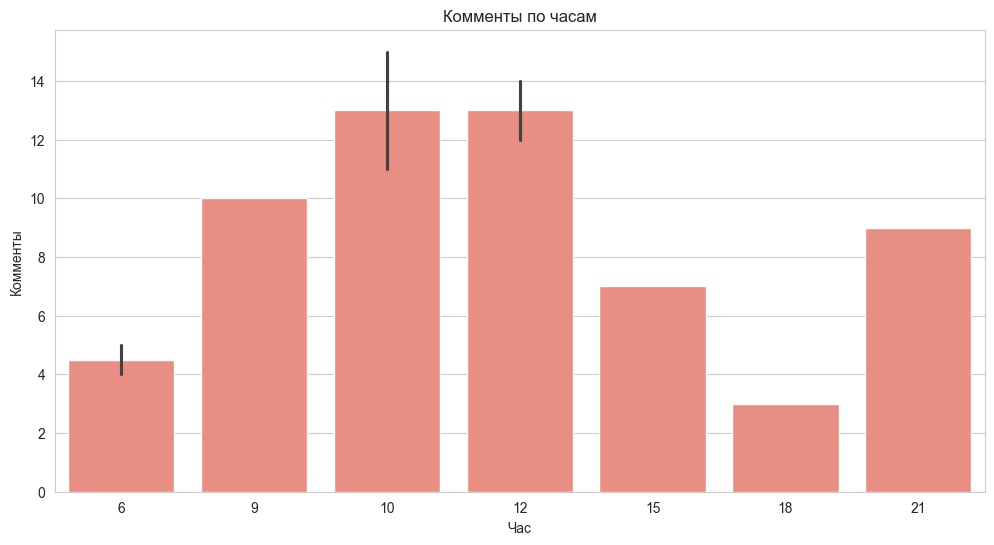

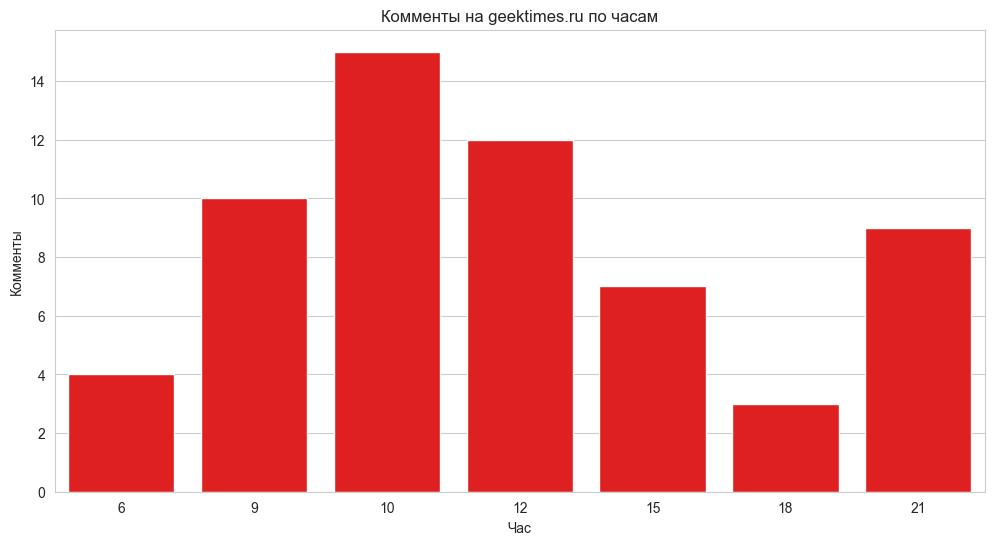

In [49]:
# просмотры по часам
plt.figure(figsize=(12, 6))
sb.barplot(data=df, x='hour', y='views', color='skyblue')
plt.title('Просмотры по часам')
plt.xlabel('Час')
plt.ylabel('Просмотры')
plt.show()

# комменты по часам
plt.figure(figsize=(12, 6))
sb.barplot(data=df, x='hour', y='comments', color='salmon')
plt.title('Комменты по часам')
plt.xlabel('Час')
plt.ylabel('Комменты')
plt.show()

# комменты гиктаймс
geek_comments = df[df['domain'] == 'geektimes.ru']
plt.figure(figsize=(12, 6))
sb.barplot(data=geek_comments, x='hour', y='comments', color='red')
plt.title('Комменты на geektimes.ru по часам')
plt.xlabel('Час')
plt.ylabel('Комменты')
plt.show()


8. Используя Seaborn, проведите визуальный анализ и определите кого из топ-20 авторов чаще всего минусуют?

9. Используя Seaborn, сравните субботы и понедельники. Правда ли, что по субботам авторы пишут в основном днём, а по понедельникам — в основном вечером?